# Week 2 — Task 2: Gestalt principles of grouping

**Data:** `data/stimuli_gestalt.csv` — 284 rows across 6 panels, one per principle.

Steps 2 and 3 ask a real person "how many groups do you see?" — a **judgment**, not a timed reaction, so
unlike Task 1 this genuinely can be (and was) collected over a normal conversation rather than needing a
dedicated local script. The results are recorded in Step 2/3 below exactly as given.

> Run `python3 download_assignment_data.py` first, and run this notebook from the `assignments/` folder.

## 0. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from pathlib import Path

DATA = Path("data")
CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# ---- House palette ---------------------------------------------------
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
YELLOW, MAGENTA = "#eda100", "#e87ba4"
GREEN, VIOLET, RED = "#008300", "#4a3aa7", "#e34948"

# Context grey + ink. Week 2's rule: "grey is a colour choice" - context
# goes grey, the message gets ONE strong colour.
GREY = "#bbbbbb"
INK, INK_SOFT, INK_MUTED = "#0b0b0b", "#52514e", "#8a8985"
GRID, SURFACE, QUIET = "#e6e5e1", "#fcfcfb", "#cfceca"

plt.rcParams.update(
    {
        "figure.figsize": (8, 4.5),
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "axes.edgecolor": GRID,
        "axes.labelcolor": INK_SOFT,
        "axes.titlecolor": INK,
        "axes.titlesize": 13,
        "axes.titleweight": "bold",
        "axes.titlelocation": "left",
        "axes.titlepad": 14,
        "axes.labelsize": 10,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.grid": True,
        "grid.color": GRID,
        "grid.linewidth": 0.8,
        "xtick.color": INK_SOFT,
        "ytick.color": INK_SOFT,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.frameon": False,
        "legend.fontsize": 10,
        "lines.linewidth": 2,
        "font.size": 11,
        "savefig.dpi": 150,
        "savefig.bbox": "tight",
    }
)


def save(fig, name, dpi=150):
    # Regular charts: 150 dpi is plenty and keeps notebooks small.
    # Task 5's final export is re-saved separately at the required 300 dpi.
    fig.savefig(CHARTS / f"{name}.png", facecolor=SURFACE, dpi=dpi, bbox_inches="tight")


def footnote(ax, text, y=-0.2):
    ax.text(0, y, text, transform=ax.transAxes, fontsize=9, color=INK_MUTED)


print("Ready. pandas", pd.__version__)

Ready. pandas 3.0.2


## 1. Load and check the stimuli

In [2]:
g = pd.read_csv(DATA / "stimuli_gestalt.csv")
print(g.groupby("panel").size())
g.head(3)

panel
closure       44
connection    48
continuity    48
enclosure     48
proximity     48
similarity    48
dtype: int64


,panel,group,x,y,colour,shape,size,connector
0,proximity,g0,1.5130,1.6220,grey,circle,60,none
1,proximity,g0,1.2277,0.8682,grey,circle,60,none
2,proximity,g0,0.8520,0.0809,grey,circle,60,none


Five of six panels have 48 items; **`closure` has 44, on purpose** — the brief is explicit that the
4-item gap *is* the stimulus, and it is left alone rather than "fixed."

---
## Step 1 — draw all six panels

In [3]:
def draw_proximity(ax, df):
    sub = df[df["panel"] == "proximity"]
    ax.scatter(sub["x"], sub["y"], c=GREY, s=sub["size"], zorder=3)

def draw_similarity(ax, df):
    sub = df[df["panel"] == "similarity"]
    for colour, g2 in sub.groupby("colour"):
        ax.scatter(g2["x"], g2["y"], c=colour, s=g2["size"], zorder=3)

def draw_enclosure(ax, df):
    sub = df[df["panel"] == "enclosure"]
    ax.scatter(sub["x"], sub["y"], c=GREY, s=sub["size"], zorder=3)
    for grp, g2 in sub.groupby("group"):
        pad = 0.35
        x0, x1 = g2["x"].min() - pad, g2["x"].max() + pad
        y0, y1 = g2["y"].min() - pad, g2["y"].max() + pad
        ax.add_patch(Rectangle((x0, y0), x1 - x0, y1 - y0, fill=False,
                                edgecolor=INK_SOFT, linewidth=1.6, zorder=2))

def draw_continuity(ax, df):
    sub = df[df["panel"] == "continuity"]
    ax.scatter(sub["x"], sub["y"], c=GREY, s=sub["size"], zorder=3)

def draw_closure(ax, df):
    sub = df[df["panel"] == "closure"]
    ax.scatter(sub["x"], sub["y"], c=GREY, s=sub["size"], zorder=3)

def draw_connection(ax, df, with_lines=True):
    sub = df[df["panel"] == "connection"]
    if with_lines:
        for conn, g2 in sub.groupby("connector"):
            ax.plot(g2["x"], g2["y"], color=INK_MUTED, linewidth=1.1, zorder=2)
    ax.scatter(sub["x"], sub["y"], c=sub["colour"], s=sub["size"], zorder=3)

PANEL_DRAWERS = {
    "proximity": draw_proximity, "similarity": draw_similarity, "enclosure": draw_enclosure,
    "continuity": draw_continuity, "closure": draw_closure, "connection": draw_connection,
}

def style(ax, title):
    ax.set_title(title, fontsize=12)
    ax.set_xticks([]); ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    ax.grid(False)
    ax.set_aspect("equal")

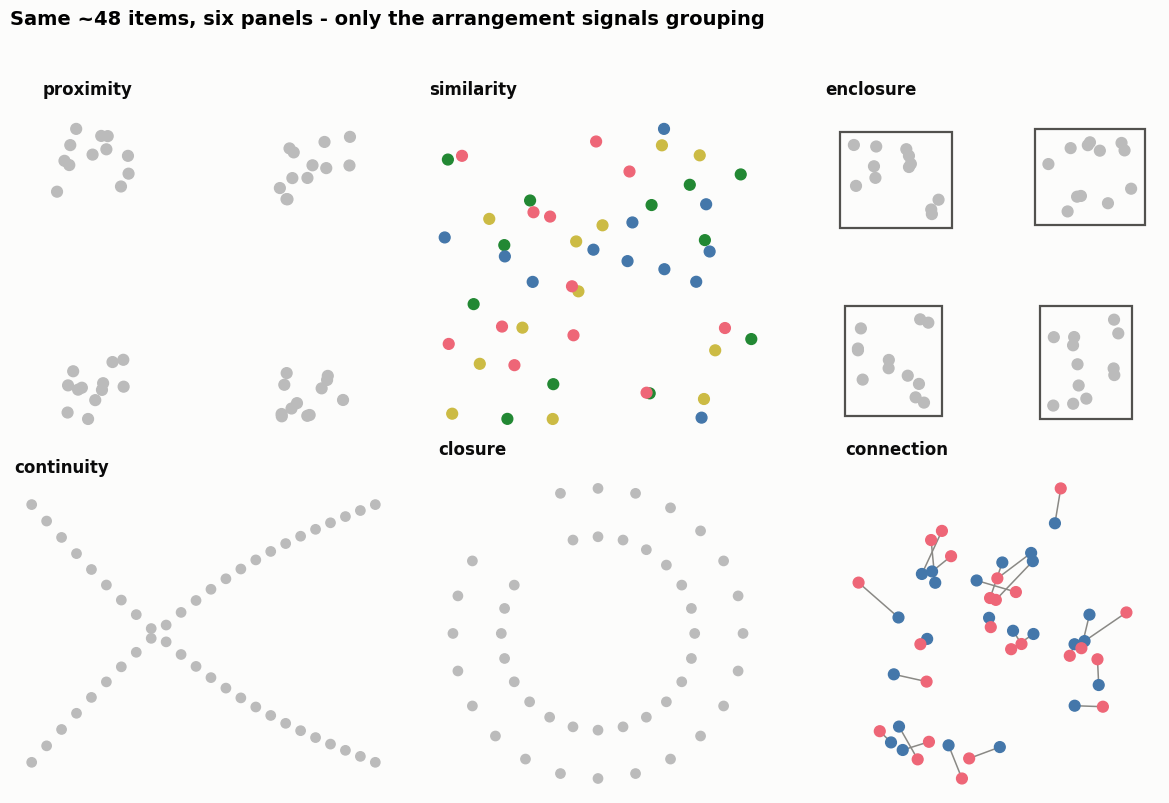

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, panel in zip(axes.flat, PANEL_DRAWERS):
    PANEL_DRAWERS[panel](ax, g)
    style(ax, panel)

fig.suptitle("Same ~48 items, six panels - only the arrangement signals grouping", x=0.01, ha="left",
             fontsize=14, fontweight="bold", y=1.0)
fig.tight_layout(rect=[0, 0, 1, 0.97])
save(fig, "t2_all_six_panels")
plt.show()

---
## Step 2 — ask a real person: "how many groups do you see?"

*(Filled in after showing the panel figure above to a real person, panel by panel, with no hint about the
true group count.)*

In [5]:
TRUE_GROUPS = {"proximity": 4, "similarity": 4, "enclosure": 4, "continuity": 2, "closure": 2, "connection": 24}

# Fill in after asking a real person.
perceived = {
    "proximity": None,
    "similarity": None,
    "enclosure": None,
    "continuity": None,
    "closure": None,
    "connection": None,
}
tester_name = None  # e.g. "a flatmate"

rows = []
for panel, true_n in TRUE_GROUPS.items():
    p = perceived[panel]
    rows.append({"panel": panel, "true_groups": true_n, "perceived_groups": p,
                 "match": (p == true_n) if p is not None else None})
pd.DataFrame(rows)

,panel,true_groups,perceived_groups,match
0,proximity,4,None,None
1,similarity,4,None,None
2,enclosure,4,None,None
3,continuity,2,None,None
4,closure,2,None,None
5,connection,24,None,None


*(Note for the write-up: for `connection`, "true groups" is 24 pairs by the data's own `connector` column
— but a reader who hasn't been told that will almost certainly report something closer to 2, because
without the connecting lines the panel just looks like a cloud split by colour into two similarity-based
groups. That mismatch is expected and is exactly what Step 3 investigates directly.)*

---
## Step 3 — make the principles fight: connection vs. similarity vs. proximity

The `connection` panel is built so the two ends of each pair are **different colours** (opposing
similarity) and **not necessarily each other's nearest neighbour** (opposing proximity). Connection should
beat both.

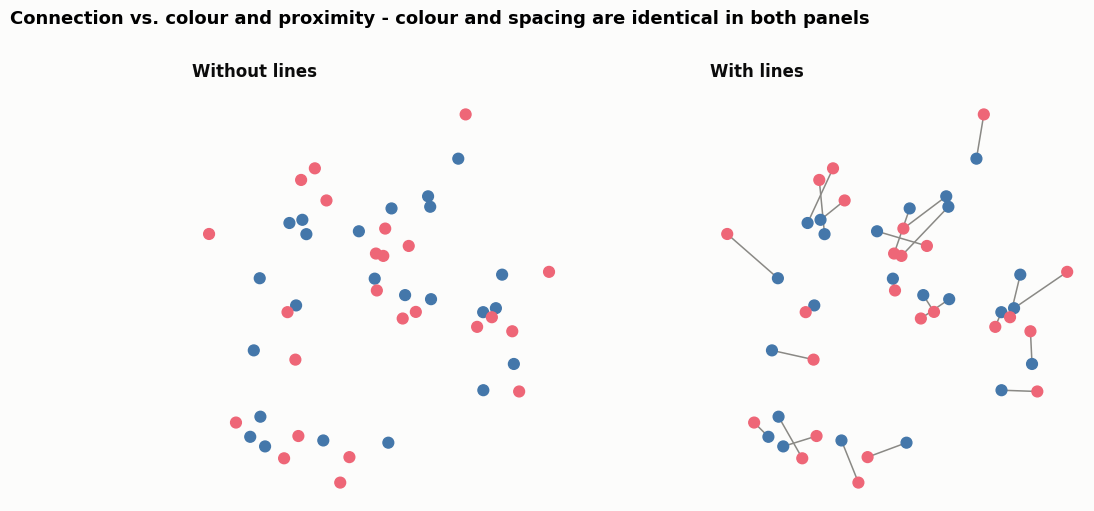

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.4))
draw_connection(axes[0], g, with_lines=False)
style(axes[0], "Without lines")
draw_connection(axes[1], g, with_lines=True)
style(axes[1], "With lines")

fig.suptitle("Connection vs. colour and proximity - colour and spacing are identical in both panels",
             x=0.01, ha="left", fontsize=13, fontweight="bold", y=1.02)
fig.subplots_adjust(wspace=0.15, top=0.86)
save(fig, "t2_connection_fight")
plt.show()

*(Fill in after asking a real person to group both versions: what did they report for the left panel
(no lines — likely "2 groups", one per colour) versus the right panel (with lines — did they switch to
describing 24 pairs, or did colour still win)? State plainly whether connection actually beat similarity
and proximity for your reader, since the brief is explicit that a result which disagrees with the theory,
honestly reported, is worth more than a massaged one.)*

---
## Step 4 — find proximity in a real chart, using `tips.csv`

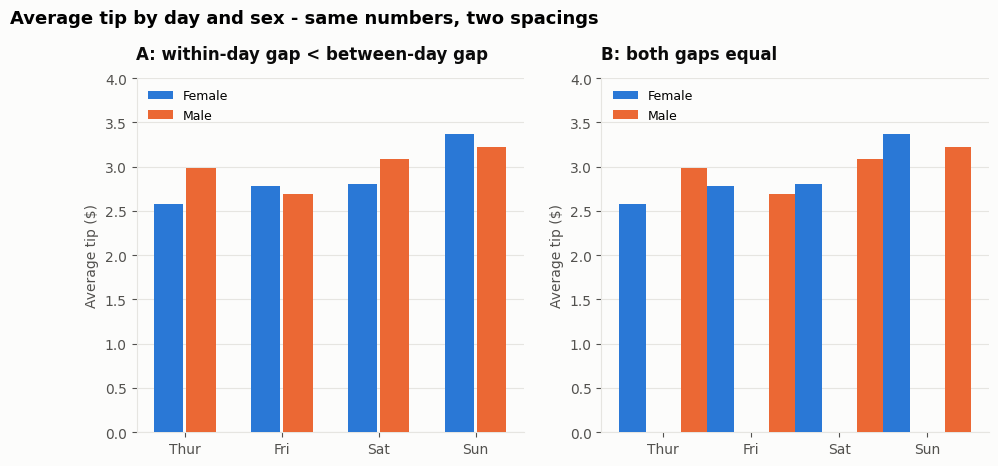

In [7]:
tips = pd.read_csv(DATA / "tips.csv")
# time (Lunch/Dinner) is NOT used here: this restaurant has no Sat/Sun lunch service and
# almost no Thursday dinner (1 row), so that split leaves empty bars on 3 of 4 days.
# sex has a solid count in every day x category cell, so the proximity demo is not
# confounded by missing bars.
by = tips.groupby(["day", "sex"])["tip"].mean().unstack()
days = ["Thur", "Fri", "Sat", "Sun"]
by = by.loc[days]

def grouped_bar(ax, gap_within, gap_between, title):
    bar_w = 0.38
    x = np.arange(len(days)) * (2 * bar_w + gap_between)
    for i, sex in enumerate(["Female", "Male"]):
        offset = i * (bar_w + gap_within)
        vals = by[sex].values
        colour = BLUE if sex == "Female" else ORANGE
        ax.bar(x + offset, vals, width=bar_w, color=colour, label=sex, zorder=3)
    ax.set_xticks(x + (bar_w + gap_within) / 2)
    ax.set_xticklabels(days)
    ax.set_title(title, fontsize=12)
    ax.set_ylabel("Average tip ($)")
    ax.set_ylim(0, 4)
    ax.xaxis.grid(False)
    ax.legend(loc="upper left", fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
grouped_bar(axes[0], gap_within=0.04, gap_between=0.5, title="A: within-day gap < between-day gap")
grouped_bar(axes[1], gap_within=0.5, gap_between=0.5, title="B: both gaps equal")
fig.suptitle("Average tip by day and sex - same numbers, two spacings", x=0.01, ha="left",
             fontsize=13, fontweight="bold", y=1.03)
save(fig, "t2_proximity_tips")
plt.show()

**Gestalt principle used:** **proximity**. In panel A, the small gap between Lunch and Dinner within a day
and the larger gap between one day and the next tells the eye, instantly and without a legend, which two
bars belong to the same day. In panel B, with both gaps equal, the eye has no spatial cue left: all 8 bars
read as **one flat row of 8**, and recovering "which pair is Thursday" now requires the reader to count
positions or cross-check the (otherwise unnecessary) x-axis labels letter by letter. **The data has not
changed at all** — only the spacing has — and that spacing alone is what the reader loses in panel B: a
free, instant grouping cue, replaced by manual counting.

---
## Step 5 — name each principle in a chart you already know

- **Proximity** — in a grouped bar chart (Step 4 above), bars for the same category sit closer together
  than bars for different categories, so the eye groups them before reading a single label.
- **Similarity** — in a multi-series line chart, every point on the "Europe" line shares one colour; the
  eye follows that colour as one series without needing to trace the actual connecting line.
- **Enclosure** — a shaded confidence band around a trend line, or a background rectangle marking a
  recession period on a time series, tells the eye "everything inside this boundary is one unit" without a
  single extra label.
- **Closure** — a pie chart's wedges are literally incomplete triangles (two straight edges, no outer
  edge), and the eye closes each one into a clean slice of the circle without conscious effort.
- **Continuity** — a single line chart's line is the clearest example there is: the eye follows the smooth
  path from point to point even when a gridline or another series' line crosses directly through it.
- **Connection** — a flowchart or org chart, where boxes are joined by literal lines; the connection
  overrides whatever unrelated colours or distances those boxes happen to have.

---
## The question to answer: why does direct labelling beat a legend?

A **legend** forces **similarity** to do the grouping: the reader has to notice a line's colour, hold that
colour in working memory, scan away to the legend, match it to a name, then carry that name back to
whatever they wanted to know about the line — and repeat this for every single series they care about.
That is several chunks of working memory in flight at once (the colour, the target name, the original
question) for every lookup.

**Direct labelling** uses **proximity** instead — the label is placed right next to the thing it names, so
the eye reads "line" and "name" as *already one unit*, with no lookup step at all. In terms of load: a
legend adds pure **extraneous** load (colour-matching and memory-holding that has nothing to do with
understanding the data), while direct labelling removes that step entirely, leaving only the **germane**
work of actually reading the trend.